In [1]:
from pathlib import Path
from ultralytics import YOLO
import json

# === CONFIG CHUNG ===

# Thư mục project hiện tại (root repo)
ROOT_DIR = Path.cwd().parent    # vì notebook nằm trong Jupyter/YOLO_33

print("ROOT_DIR:", ROOT_DIR)

# Thư mục ảnh 33 món ăn (mỗi món 1 folder)
DATA_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls")
print("DATA_DIR tồn tại?", DATA_DIR.exists())

# Thư mục YOLO auto-split sẽ tạo (train/val)
SPLIT_DIR = DATA_DIR.parent / "Images_split"
print("SPLIT_DIR:", SPLIT_DIR)

# Thư mục lưu các run YOLO-CLS 33
RUNS_ROOT  = ROOT_DIR / "YOLO_33/runs_yolo_cls33"
RUN_NAME   = "MTL_FOOD33_CLS_01"

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
print("RUNS_ROOT:", RUNS_ROOT)


ROOT_DIR: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter
DATA_DIR tồn tại? True
SPLIT_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split
RUNS_ROOT: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33


In [ ]:
# Lấy class trong folder train để chắc dataset ok
train_dir = DATA_DIR / "train"
classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])

print("Tổng số lớp:", len(classes))
print(classes[:10], "...")

# Lưu luôn tên class để sau này app dùng
runs_meta_dir = ROOT_DIR / "YOLO_33/runs_meta"
runs_meta_dir.mkdir(exist_ok=True)

cls_json_path = runs_meta_dir / "yolo_cls33_class_names.json"
with open(cls_json_path, "w", encoding="utf-8") as f:
    json.dump(classes, f, ensure_ascii=False, indent=2)

print("✅ Đã lưu class_names vào:", cls_json_path)


Tổng số lớp: 34
['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi'] ...
✅ Đã lưu class_names vào: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_meta/yolo_cls33_class_names.json


In [ ]:
MODEL = "yolo11s-cls.pt"   # hoặc yolo11m-cls.pt nếu GPU khỏe

print("MODEL:", MODEL)

model = YOLO(MODEL)

# Nếu SPLIT_DIR chưa tồn tại, YOLO sẽ tự chia 80/20.
# Nếu đã có, nó xài lại, không chia nữa.
print("Bắt đầu train YOLO-CLS 33 lớp...")

results = model.train(
    data=str(DATA_DIR),    # 👉 CHỈ ĐIỂM TỚI FOLDER GỐC, KHÔNG PHẢI YAML
    epochs=50,
    imgsz=224,
    batch=32,
    device=0,              # 0 = GPU
    project=str(RUNS_ROOT),
    name=RUN_NAME,
)

print("✅ Train xong.")


MODEL: yolo11s-cls.pt
Bắt đầu train YOLO-CLS 33 lớp...
Ultralytics 8.3.229 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 5000, 15925MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=MTL_FOOD33_CLS_012, nbs=64, nms=False, opset=

libpng warning: iCCP: known incorrect sRGB profile


val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 307.8±368.9 MB/s, size: 369.1 KB)
val: Scanning /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val... 3534 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3534/3534 823.9Kit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33/MTL_FOOD33_CLS_012
Starting training for 50 epochs...

      Epoch    GPU_mem       loss  Instances       Size
       1/50     0.863G      3.643         32        224: 1% ──────────── 7/708 6.3it/s 1.7s<1:51

libpng warning: iCCP: known incorrect sRGB profile


       1/50     0.863G      3.671         32        224: 3% ──────────── 23/708 8.1it/s 4.5s<1:24

...

train: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/train... found 22635 images in 34 classes ✅ 
val: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val... found 3534 images in 34 classes ✅ 
test: None...
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 56/56 11.9it/s 4.7s0.2s


libpng warning: iCCP: known incorrect sRGB profile


                   all      0.892      0.981
Speed: 0.2ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33/MTL_FOOD33_CLS_012


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB


✅ Train xong.


DANH GIA MO HINH

In [ ]:
from pathlib import Path
from ultralytics import YOLO

# === Load best weights ===
ROOT_DIR = Path.cwd().parent
RUNS_ROOT = ROOT_DIR / "YOLO_33/runs_yolo_cls33"
RUN_NAME  = "MTL_FOOD33_CLS_01"

BEST_WEIGHTS = RUNS_ROOT / RUN_NAME / "weights" / "best.pt"
print("BEST_WEIGHTS:", BEST_WEIGHTS, "tồn tại?", BEST_WEIGHTS.exists())

cls_model = YOLO(str(BEST_WEIGHTS))
print("✅ Loaded best YOLO-CLS")

# === Đường dẫn dataset split do YOLO tạo ===
DATA_DIR   = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls")
SPLIT_DIR  = DATA_DIR.parent / "Images_split"   # root: có train/ và val/
print("SPLIT_DIR:", SPLIT_DIR, "tồn tại?", SPLIT_DIR.exists())

# === Đánh giá trên val ===
# Để YOLO tự split lại khi đánh giá
metrics = model.val(
    data=str(DATA_DIR),  # trỏ vào folder Images gốc
    split='val',         # dùng 20% val
    imgsz=224,
    device=0
)

print("✅ Đánh giá xong.")
print("Top-1 acc:", metrics.top1)
print("Top-5 acc:", metrics.top5)


BEST_WEIGHTS: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt tồn tại? True
✅ Loaded best YOLO-CLS
SPLIT_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split tồn tại? True
Ultralytics 8.3.229 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 5000, 15925MiB)
YOLO11s-cls summary (fused): 47 layers, 5,477,682 parameters, 0 gradients, 12.0 GFLOPs
train: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/train... found 22635 images in 34 classes ✅ 
val: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val... found 3534 images in 34 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 1240.0±1878.7 MB/s, size: 369.1 KB)
val: Scanning /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val... 3534 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3534/3534 4.9Mit/s 0.0s0s


libpng warning: iCCP: known incorrect sRGB profile


               classes   top1_acc   top5_acc: 28% ━━━───────── 61/221 20.7it/s 5.3s<7.7ss

libpng warning: iCCP: known incorrect sRGB profile


               classes   top1_acc   top5_acc: 81% ━━━━━━━━━╸── 179/221 36.6it/s 13.1s<1.1s

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB


               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 221/221 12.8it/s 17.2s<0.0s
                   all      0.893      0.982
Speed: 0.2ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/runs/classify/val5
✅ Đánh giá xong.
Top-1 acc: 0.8930390477180481
Top-5 acc: 0.9816072583198547


In [1]:
# Cell: Tạo list ảnh VAL + nhãn thật

from pathlib import Path
import json
import numpy as np
import random

# Đường dẫn DATA_DIR và ROOT_DIR đã có ở trên, nhưng cứ chắc ăn:
ROOT_DIR = Path.cwd()          # đang ở Jupyter/YOLO_33
DATA_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val")

print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR, "tồn tại?", DATA_DIR.exists())

# Load lại class_names cho chắc
cls_json_path = ROOT_DIR / "runs_meta" / "yolo_cls33_class_names.json"
with open(cls_json_path, "r", encoding="utf-8") as f:
    class_names = json.load(f)

num_classes = len(class_names)
print("Số lớp:", num_classes)

# Tự chia 80/20: lấy 20% cuối mỗi lớp làm val
VAL_IMAGES = []
VAL_LABELS = []

random.seed(1337)

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = DATA_DIR / cls_name
    img_files = sorted(
        [p for p in cls_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    )
    if not img_files:
        print(f"⚠️ Lớp {cls_name} không có ảnh nào, bỏ qua.")
        continue

    # 80/20
    split_idx = int(len(img_files) * 0.8)
    val_files = img_files[split_idx:]

    VAL_IMAGES.extend(val_files)
    VAL_LABELS.extend([cls_idx] * len(val_files))

print(f"Tổng ảnh VAL: {len(VAL_IMAGES)}")
print("Ví dụ 5 ảnh đầu:")
for i in range(min(5, len(VAL_IMAGES))):
    print(" ", VAL_IMAGES[i], " | class:", class_names[VAL_LABELS[i]])


ROOT_DIR: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33
DATA_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val tồn tại? True
Số lớp: 34
Tổng ảnh VAL: 709
Ví dụ 5 ảnh đầu:
  /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val/Banh beo/607.jpg  | class: Banh beo
  /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val/Banh beo/608.jpg  | class: Banh beo
  /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val/Banh beo/61.jpg  | class: Banh beo
  /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val/Banh beo/617.jpg  | class: Banh beo
  /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val/Banh beo/62.jpg  | class: Banh beo


In [2]:
# Cell: Chạy model trên VAL để lấy y_true / y_pred

from tqdm.auto import tqdm

y_true = []
y_pred = []

# model đã load BEST_WEIGHTS ở trên (nếu chưa thì load lại):
# from ultralytics import YOLO
# BEST_WEIGHTS = ROOT_DIR / "runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt"
# model = YOLO(str(BEST_WEIGHTS))

for img_path, label in tqdm(list(zip(VAL_IMAGES, VAL_LABELS)), desc="Đang dự đoán VAL"):
    # Gọi model -> trả list Results, lấy phần tử 0
    res = model(str(img_path), imgsz=224, device=0, verbose=False)[0]

    probs = res.probs  # kiểu Probs
    # lớp dự đoán là index có xác suất cao nhất
    pred_idx = int(probs.top1)        # top1 = chỉ số class cao nhất

    y_true.append(label)
    y_pred.append(pred_idx)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Đã dự đoán xong. Ví dụ 10 mẫu đầu:")
for i in range(min(10, len(y_true))):
    print(f"{i:02d}. GT: {class_names[y_true[i]]:20s} | Pred: {class_names[y_pred[i]]:20s}")


Đang dự đoán VAL:   0%|          | 0/709 [00:00<?, ?it/s]

NameError: name 'model' is not defined

In [ ]:
# Cell: Vẽ Confusion Matrix theo từng class

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)  # chuẩn hoá theo từng hàng (theo GT)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')

ax.set_title("Confusion Matrix (chuẩn hoá theo từng lớp GT)")
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Nhãn thật")

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)

# Ghi số % lên từng ô (ẩn mấy ô NaN nếu lớp không có mẫu)
for i in range(num_classes):
    for j in range(num_classes):
        if np.isnan(cm_norm[i, j]):
            continue
        val = cm_norm[i, j] * 100
        if val < 0.5:
            continue
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=7, color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


<Figure size 1200x1000 with 2 Axes>

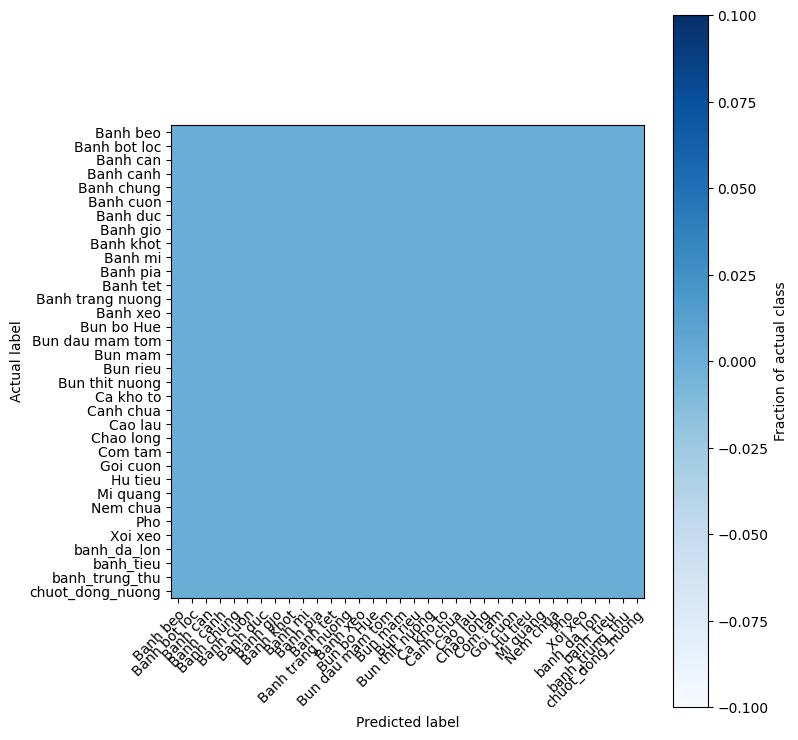

In [3]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Tính confusion matrix (bao gồm tất cả các lớp trong class_names theo đúng thứ tự)
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
cm = cm.astype(float)
# Chuẩn hóa theo hàng (tính tỉ lệ phần trăm mỗi hàng)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums!=0)

# Tạo biểu đồ heatmap
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
cbar = fig.colorbar(im, ax=ax)  # thanh màu biểu thị mức phần trăm
cbar.set_label('Fraction of actual class')  # nhãn cho thanh màu (có thể tùy chỉnh hoặc bỏ)

# Cài đặt nhãn trục và tiêu đề trục
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_ylabel('Actual label')
ax.set_xlabel('Predicted label')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")  # xoay nhãn trục X cho đỡ chồng

# Chú thích giá trị phần trăm trong từng ô của ma trận
thresh = cm_norm.max() / 2.0  # ngưỡng để đổi màu chữ (một nửa giá trị lớn nhất)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        value = cm_norm[i, j] * 100  # quy đổi thành %
        if value < 0.5: 
            continue  # bỏ qua giá trị nhỏ hơn 0.5%
        text = f"{value:.1f}%"  # định dạng một chữ số thập phân
        if value >= 99.95: 
            text = "100%"      # chỉnh lại hiển thị 100% cho đẹp (nếu có)
        color = "white" if cm_norm[i, j] > thresh else "black"
        ax.text(j, i, text, ha="center", va="center", color=color)

fig.tight_layout()  # căn chỉnh layout cho đẹp, tránh trùng nhãn
# Tạo thư mục lưu ảnh nếu chưa tồn tại
Path("./images").mkdir(parents=True, exist_ok=True)
# Lưu biểu đồ thành file PNG độ phân giải 300 DPI
fig.savefig("images/confusion_matrix.png", dpi=300)
plt.show()



In [4]:
# Cell: Bảng Precision / Recall / F1 theo từng lớp

from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(num_classes)), zero_division=0
)

print(f"{'ID':>2} {'Class':25s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Support':>8}")
print("-" * 60)
for i, name in enumerate(class_names):
    print(f"{i:2d} {name:25s} {prec[i]:7.3f} {rec[i]:7.3f} {f1[i]:7.3f} {support[i]:8d}")


ID Class                        Prec     Rec      F1  Support
------------------------------------------------------------


ValueError: Unknown format code 'd' for object of type 'float'

In [ ]:
DU DOAN MO HINH

In [5]:
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import numpy as np
import json

# ==== PATH CƠ BẢN ====
YOLO33_DIR = Path.cwd()              # đang ở Jupyter/YOLO_33
PROJ_ROOT = YOLO33_DIR.parent        # folder gốc project

print("YOLO33_DIR:", YOLO33_DIR)
print("PROJ_ROOT:", PROJ_ROOT)

# 1) Model DETECTOR (tìm vùng có món ăn trên bàn)
DET_WEIGHTS = PROJ_ROOT / "Yolo/MTL_FOOD_PLATE_01" / "weights" / "best.pt"
print("DET_WEIGHTS:", DET_WEIGHTS, "tồn tại?", DET_WEIGHTS.exists())

det_model = YOLO(str(DET_WEIGHTS))
print("✅ Loaded detector:", DET_WEIGHTS)

# 2) Model CLASSIFIER 33 món (YOLO-CLS)
CLS_WEIGHTS = YOLO33_DIR / "runs_yolo_cls33" / "MTL_FOOD33_CLS_01" / "weights" / "best.pt"
print("CLS_WEIGHTS:", CLS_WEIGHTS, "tồn tại?", CLS_WEIGHTS.exists())

cls_model = YOLO(str(CLS_WEIGHTS))
print("✅ Loaded classifier:", CLS_WEIGHTS)

# 3) Load tên lớp 33 món
cls_json_path = YOLO33_DIR / "runs_meta" / "yolo_cls33_class_names.json"
with open(cls_json_path, "r", encoding="utf-8") as f:
    CLASS_NAMES = json.load(f)

NUM_CLASSES = len(CLASS_NAMES)
print("Số lớp:", NUM_CLASSES)
print("Một vài lớp:", CLASS_NAMES[:8])


YOLO33_DIR: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33
PROJ_ROOT: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter
DET_WEIGHTS: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/Yolo/MTL_FOOD_PLATE_01/weights/best.pt tồn tại? True
✅ Loaded detector: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/Yolo/MTL_FOOD_PLATE_01/weights/best.pt
CLS_WEIGHTS: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt tồn tại? True
✅ Loaded classifier: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt
Số lớp: 34
Một vài lớp: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio']


In [6]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# det_model: YOLO detector đã load ở cell trước
# YOLO33_DIR: thư mục gốc cho phần YOLO_33 (đã khai báo trước đó)

def detect_food_boxes(
    img_path,
    conf_thres: float = 0.4,
    save_dir: Path | None = None,
    show: bool = True,
):
    """
    Detect tất cả món ăn trên ảnh bàn ăn bằng YOLO-CLS 33,
    vẽ bounding box + score lên ảnh và (tuỳ chọn) lưu xuống đĩa.

    Trả về:
        img_pil  : ảnh gốc dạng PIL.Image
        boxes    : list[(x1, y1, x2, y2)]
        draw_img : ảnh đã vẽ box (PIL.Image)
        save_path: đường dẫn file đã lưu (hoặc None)
    """


    
    img_path = Path(img_path)
    print("Test image:", img_path)

    # ==== 1. LOAD ẢNH GỐC ====
    img_pil = Image.open(img_path).convert("RGB")

    # ==== 2. CHẠY YOLO DETECT ====
    results = det_model.predict(
        source=str(img_path),
        conf=conf_thres,
        imgsz=640,      # detect nên để 640 cho YOLO
        device=0,       # 0 = GPU, nếu lỗi CUDA nó tự fallback CPU
        verbose=False,
    )
    res = results[0]

    boxes = []
    if res.boxes is not None:
        for b in res.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0].cpu().numpy().tolist())
            boxes.append((x1, y1, x2, y2))

    print(f"🔎 Detect được {len(boxes)} box.")

    # ==== 3. VẼ BOX LÊN ẢNH ====
    draw_img = img_pil.copy()
    draw = ImageDraw.Draw(draw_img)

    # font chữ
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except OSError:
        font = ImageFont.load_default()

    for i, (x1, y1, x2, y2) in enumerate(boxes):
        conf = float(res.boxes[i].conf.cpu().item())
        label = f"{conf:.2f}"

        # --- Lấy kích thước text: ưu tiên textbbox (Pillow mới), fallback textsize (Pillow cũ) ---
        try:
            bbox = draw.textbbox((0, 0), label, font=font)
            tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except AttributeError:
            # dành cho Pillow cũ (<10)
            tw, th = draw.textsize(label, font=font)

        # khung đỏ
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        # nền vàng sau label
        text_bg = [x1, y1 - th - 4, x1 + tw + 4, y1]
        draw.rectangle(text_bg, fill="yellow")

        # chữ đen
        draw.text((x1 + 2, y1 - th - 2), label, font=font, fill="black")

    # ==== 4. LƯU ẢNH NẾU CẦN ====
    save_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / f"{img_path.stem}_det_only.jpg"
        draw_img.save(save_path)
        print("💾 Đã lưu ảnh detect-only tại:", save_path)

    # ==== 5. HIỂN THỊ TRÊN NOTEBOOK ====
    if show:
        plt.figure(figsize=(8, 6))
        plt.imshow(draw_img)
        plt.axis("off")
        plt.show()

    print("✅ Detect xong.")

    return img_pil, boxes, draw_img, save_path


Test image: /home/mtl/Downloads/6.jpg
🔎 Detect được 18 box.
💾 Đã lưu ảnh detect-only tại: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/images_detect/det_only/6_det_only.jpg


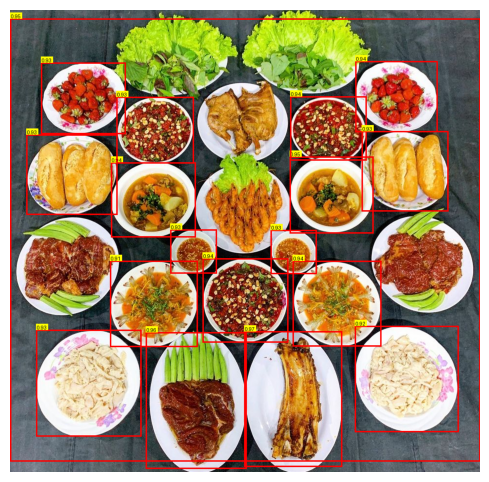

✅ Detect xong.
Số box detect được: 18
File đã lưu: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/images_detect/det_only/6_det_only.jpg


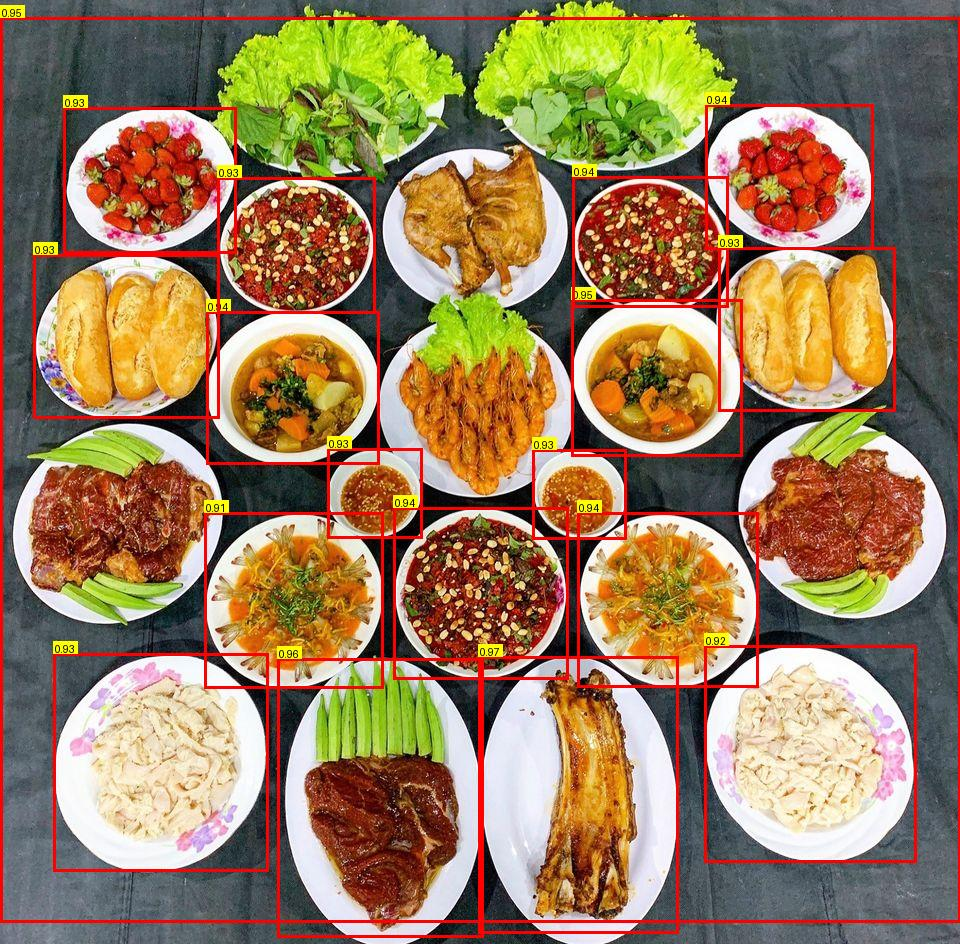

In [7]:
from pathlib import Path
from PIL import Image
from IPython.display import display
# ảnh bàn ăn thật ngoài đời
test_img = Path("/home/mtl/Downloads/6.jpg")  # đổi path tuỳ ý

img_pil, boxes, det_vis, det_save = detect_food_boxes(
    test_img,
    conf_thres=0.9,
    save_dir=YOLO33_DIR / "images_detect" / "det_only",
    show=True,
)

print("Số box detect được:", len(boxes))
print("File đã lưu:", det_save)

# 5) Hiển thị trực quan ngay trong notebook (dùng display cho chắc)
# det_save là Path tới file đã lưu
img_show = Image.open(det_save)
display(img_show)

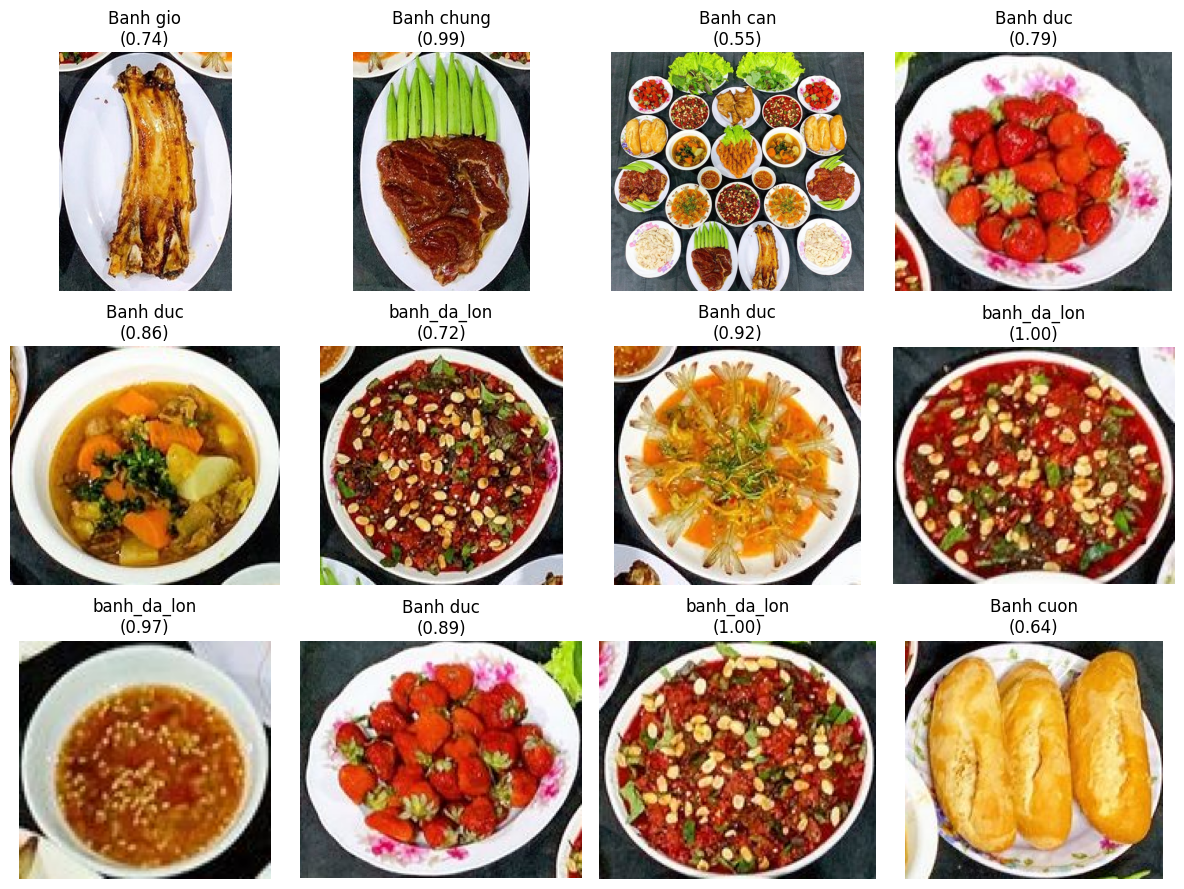

✅ Classify xong.
Đếm theo món:
 - Banh gio: 1
 - Banh chung: 1
 - Banh can: 1
 - Banh duc: 6
 - banh_da_lon: 5
 - Banh cuon: 2


In [8]:
import math

def crop_and_classify(img_pil, boxes, prob_thres=0.5, save_dir=None, max_show=12):
    """
    Crop từng box -> YOLO-CLS 33 món -> trả kết quả + vẽ grid crop.

    Trả về:
      results: list dict { 'box', 'cls_idx', 'cls_name', 'prob', 'crop_path' }
      counts : dict { 'Tên món': số lượng }
    """
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    results = []
    counts = {}
    crops_to_show = []

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        crop = img_pil.crop((x1, y1, x2, y2))

        pred = cls_model.predict(
            source=np.array(crop),
            imgsz=224,
            device=0,
            verbose=False,
        )[0]

        probs = pred.probs
        top_idx = int(probs.top1)
        top_prob = float(probs.top1conf)

        # bỏ những box classifier không tự tin
        if top_prob < prob_thres:
            continue

        cls_name = CLASS_NAMES[top_idx]

        crop_path = None
        if save_dir is not None:
            crop_path = save_dir / f"{Path(test_img).stem}_box{idx+1}_{cls_name}.jpg"
            crop.save(crop_path)

        results.append({
            "box": box,
            "cls_idx": top_idx,
            "cls_name": cls_name,
            "prob": top_prob,
            "crop_path": str(crop_path) if crop_path else None,
        })

        counts[cls_name] = counts.get(cls_name, 0) + 1

        if len(crops_to_show) < max_show:
            crops_to_show.append((crop, cls_name, top_prob))

    # Vẽ grid crop + tên món
    if crops_to_show:
        n = len(crops_to_show)
        cols = 4
        rows = math.ceil(n / cols)
        plt.figure(figsize=(3 * cols, 3 * rows))
        for i, (crop, name, prob) in enumerate(crops_to_show, start=1):
            plt.subplot(rows, cols, i)
            plt.imshow(crop)
            plt.axis("off")
            plt.title(f"{name}\n({prob:.2f})")
        plt.tight_layout()
        plt.show()

    print("✅ Classify xong.")
    print("Đếm theo món:")
    for name, c in counts.items():
        print(f" - {name}: {c}")

    return results, counts


results, counts = crop_and_classify(
    img_pil,
    boxes,
    prob_thres=0.5,
    save_dir=YOLO33_DIR / "images_detect" / "crops",
    max_show=12,
)
